## 基于token num拟合TTFT和TPOT
+ 对于TTFT：所有seq的token num之和
+ 对于TPOT：batch_size

In [ ]:

from benchmark_test.analysis.profile.profile import InstanceProfile, InstanceDecodeProfiler
import numpy as np
from statistics import mean
import matplotlib.pyplot as plt


Loaded cached results from /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-13b/poisson/tp1_instance_profile_results.json
Lower bound: -184.45637822151184, Upper bound: 503.54644656181335
prefill fit_results:[1.81398227e-05 1.95004570e-01 4.28748880e+01]
RMSE: 9.0078
decode fit_results:[-1.56133580e-02  1.71119796e+00  3.87670986e+01]
RMSE: 2.2894
Lower bound: 30.93315069995176, Upper bound: 117.2829117786997


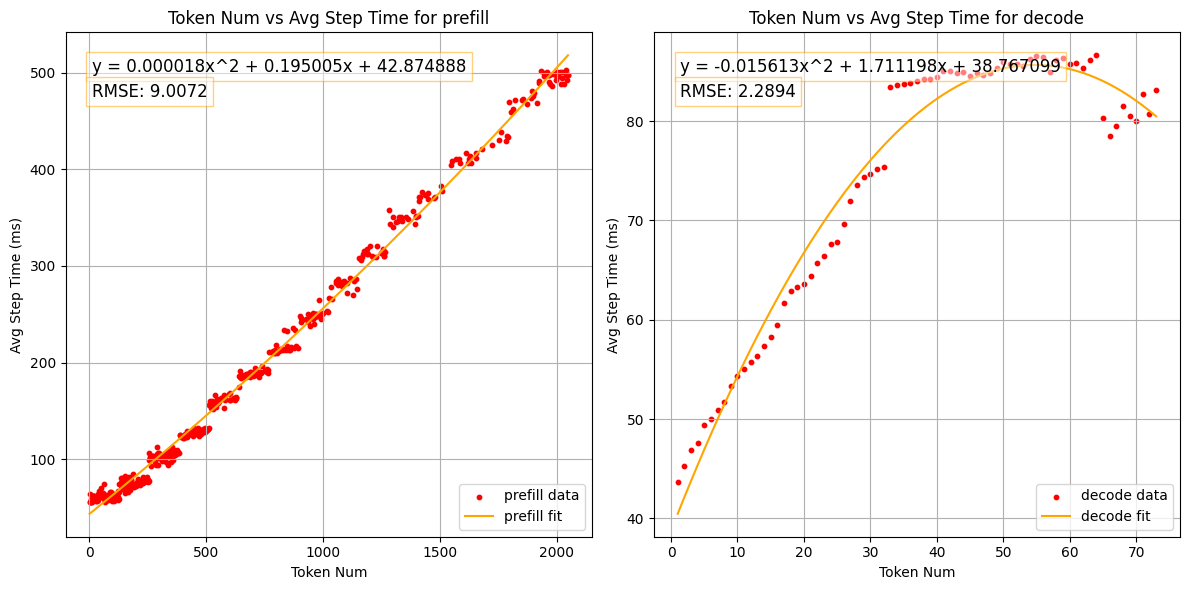

In [ ]:
instance_file_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-13b/poisson'

# instance_file_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-test-128-256/llama-13b/poisson'
instance_profile = InstanceProfile(instance_file_dir,'tp1', enable_pd=True)
instance_profile.get_pdd_instance_info()
instance_profile.plot_token_num_vs_avg_step_time()
# instance_profile.fit_certain_data()

## 基于batch_size和seq_len二元拟合TPOT

Loaded cached results from /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-13b/poisson/tp1_instance_decode_profile_results.json
First key type: <class 'tuple'>, value type: <class 'list'>
filter_count: 0
x_val shape: (158295, 2), y_val shape: (158295,)
Lower bound: 20.356376965840646, Upper bound: 114.05551433563232
fit_results:36.007725188578675 + [0.95296822 0.015518  ]
RMSE: 3.8035


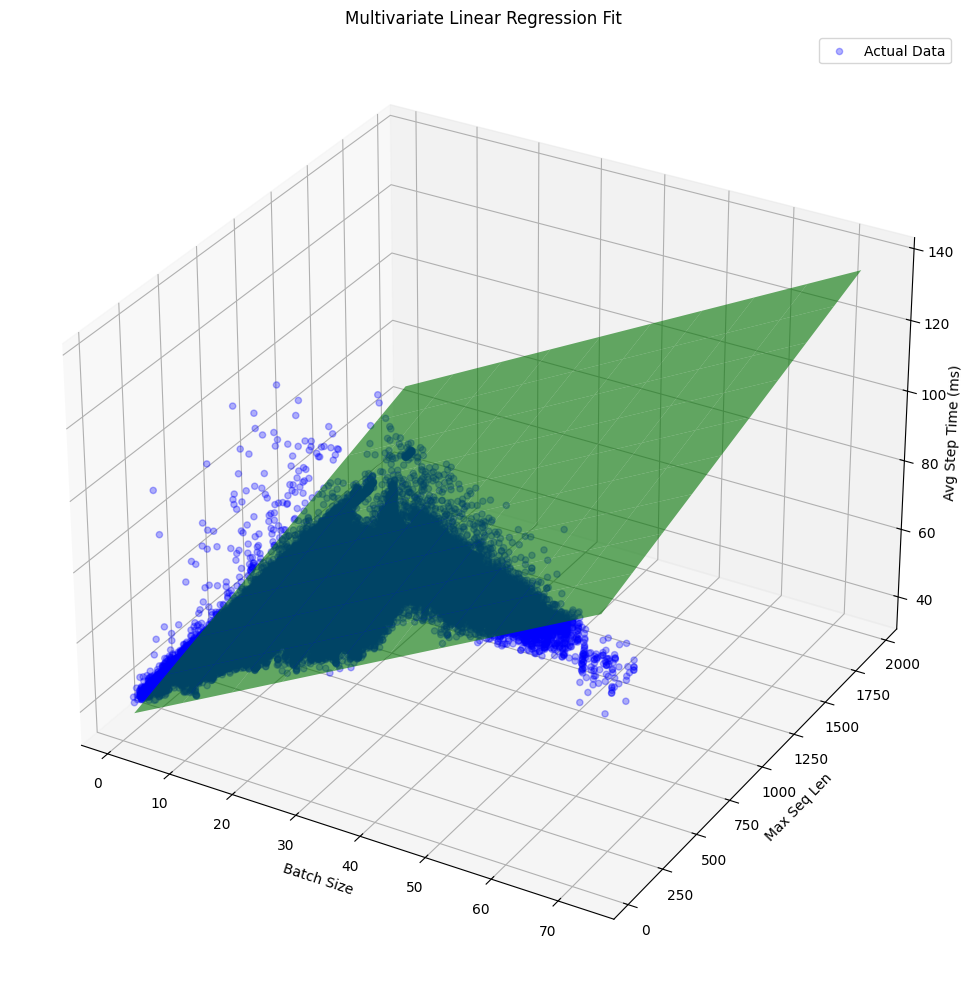

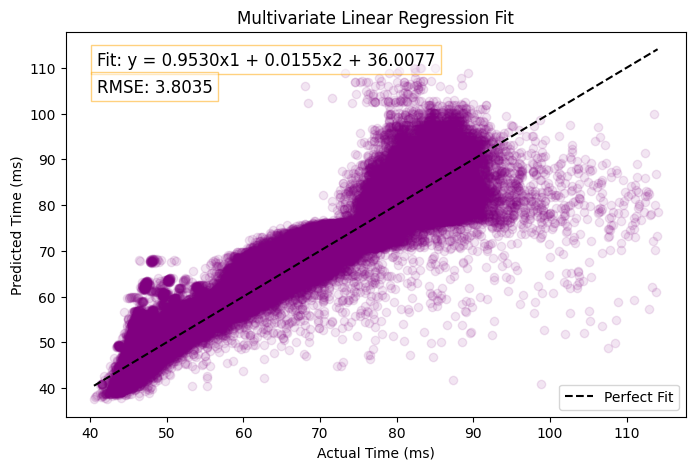

In [ ]:
from benchmark_test.analysis.profile.profile import InstanceProfile, InstanceDecodeProfiler
import matplotlib.pyplot as plt
instance_file_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-13b/poisson'
instance_profile = InstanceDecodeProfiler(instance_file_dir, enable_pd=True)
instance_profile.get_pdd_instance_info()
print(f"filter_count: {instance_profile.filter_count}")
y_pred = instance_profile.plot_result()

# 对比原始数据与预测
y = instance_profile.y_values
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred, c='purple', alpha=0.1, )
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='Perfect Fit')
# 显示表达式
plt.text(0.05, 0.95, f'Fit: y = {instance_profile.model.coef_[0]:.4f}x1 + {instance_profile.model.coef_[1]:.4f}x2 + {instance_profile.model.intercept_:.4f}', 
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
plt.text(0.05, 0.88, f'RMSE: {instance_profile.rmse:.4f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
plt.xlabel('Actual Time (ms)')
plt.ylabel('Predicted Time (ms)')
plt.title('Multivariate Linear Regression Fit')  # 多元线性拟合
plt.legend()
plt.show()


RMSE: 4.0169
Nonlinear Fit Parameters: [-1.27035164e-03 -1.20740278e-07  4.25835829e-05  5.91933437e-01
  3.65207695e-03  2.21035882e+01]
Expression: y = -0.001270x1^2 + -0.000000x2^2 + 0.000043x1x2 + 0.591933x1 + 0.003652x2 + 22.103588


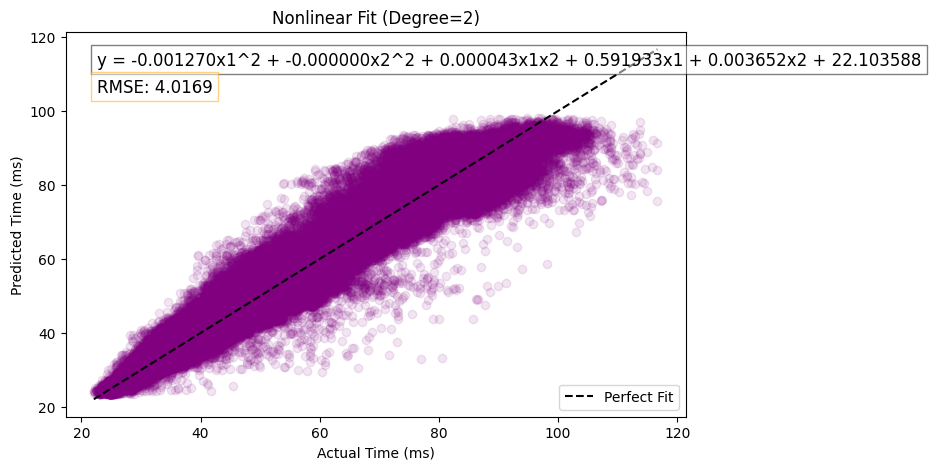

In [4]:
from scipy.optimize import curve_fit

# 定义非线性模型（示例：二次函数含交互项）
def nonlinear_model(X, a, b, c, d, e, f):
    x1, x2 = X[:, 0], X[:, 1]
    return a * x1**2 + b * x2**2 + c * x1 * x2 + d * x1 + e * x2 + f
X = instance_profile.x_values
y = instance_profile.y_values
# 拟合非线性模型
params, _ = curve_fit(nonlinear_model, X, y, p0=[1, 1, 1, 1, 1, 1])
y_pred_nl = nonlinear_model(X, *params)
# print(nonlinear_model(np.array([[18.66, 256]]), *params))  # 测试预测
# 计算拟合的均方根误差
rmse = np.sqrt(np.mean((y-y_pred_nl) ** 2))
print(f"RMSE: {rmse:.4f}")
print(f"Nonlinear Fit Parameters: {params}")
# 对比原始数据与预测
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred_nl, c='purple', alpha=0.1, )
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='Perfect Fit')
# 显示表达式
expression = f"y = {params[0]:.6f}x1^2 + {params[1]:.6f}x2^2 + {params[2]:.6f}x1x2 + {params[3]:.6f}x1 + {params[4]:.6f}x2 + {params[5]:.6f}"
print(f"Expression: {expression}")
plt.text(0.05, 0.95, expression, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
plt.text(0.05, 0.88, f'RMSE: {rmse:.4f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
plt.xlabel('Actual Time (ms)')
plt.ylabel('Predicted Time (ms)')
plt.title('Nonlinear Fit (Degree=2)')
plt.legend()
plt.show()


Polynomial Fit RMSE: 4.0169


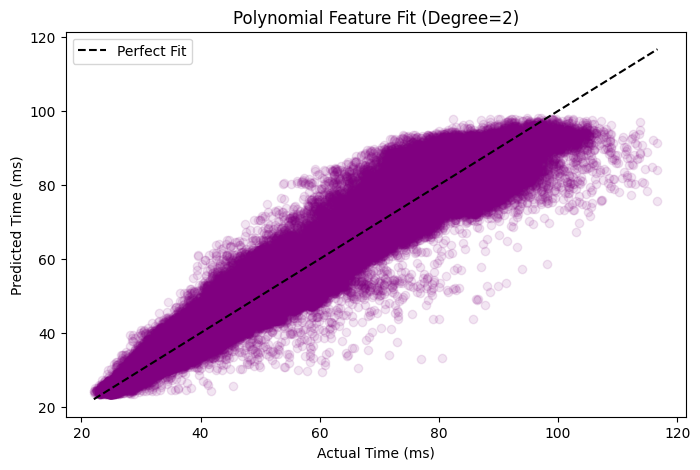

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# 生成二阶多项式特征（含交互项）
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# 拟合扩展后的线性模型
model_poly = LinearRegression()
model_poly.fit(X_poly, y)
y_pred_poly = model_poly.predict(X_poly)
# 计算拟合的均方根误差
rmse_poly = np.sqrt(np.mean((y - y_pred_poly) ** 2))
print(f"Polynomial Fit RMSE: {rmse_poly:.4f}")

# 对比原始数据与预测
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred_poly, c='purple', alpha=0.1, )
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='Perfect Fit')
plt.xlabel('Actual Time (ms)')
plt.ylabel('Predicted Time (ms)')
plt.title('Polynomial Feature Fit (Degree=2)')
plt.legend()
plt.show()


x.shape: (266991,), y.shape: (266991,)
Fitting results: [-3.75728209e-09  1.29684479e-03  2.61126977e+01]
RMSE: 3.2596


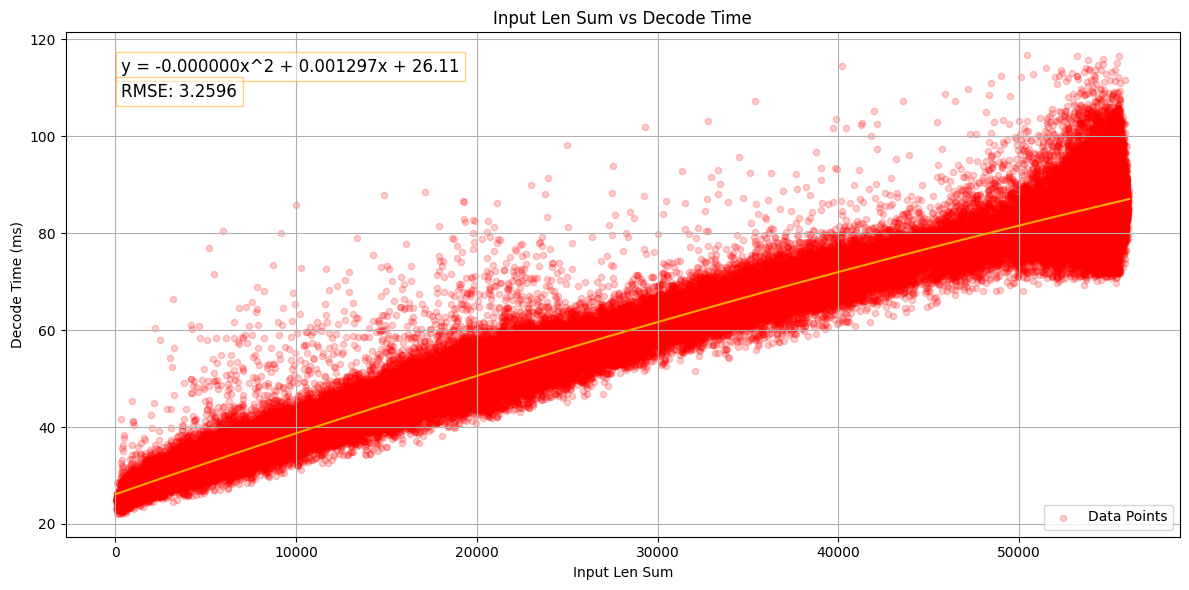

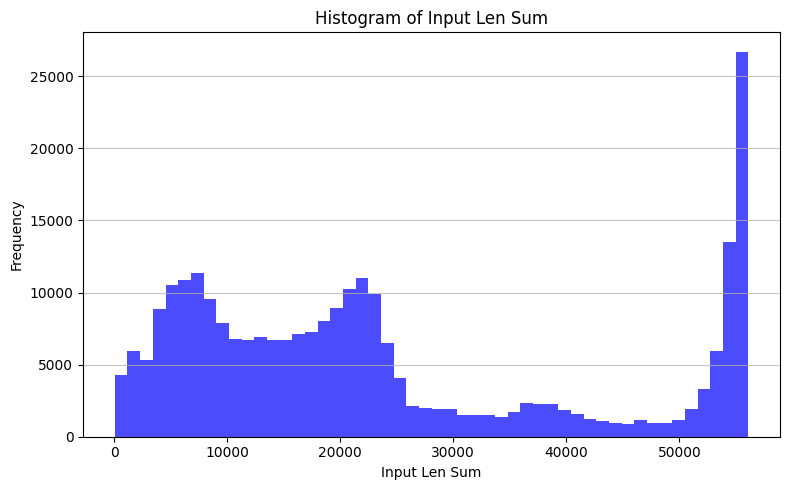

In [7]:
# 拟合token_num和avg_step_time的关系
def fit_data(x, y):

    if len(x) < 2:
        print(f"Not enough data to fit.")
        return None
    
    # 使用numpy的polyfit进行线性拟合
    coefficients = np.polyfit(x, y, 2)

    fit_results = coefficients
    return fit_results

# 绘制token_num和avg_step_time的关系图,使用matplotlib,
def plot_data(x,y,x_label='Input Len', y_label='Decode Time (ms)', title='Input Len vs Decode Time (Batch Size: 32)'):
    # 分配两个子图
    fig, axs = plt.subplots(1, 1, figsize=(12, 6))

    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    # 剔除异常值
    # if len(x) > 20:
    #     # 基于IQR方法剔除异常值
    #     q1 = np.percentile(y, 25)
    #     q3 = np.percentile(y, 75)
    #     iqr = q3 - q1
    #     lower_bound = q1 - 1.5 * iqr
    #     upper_bound = q3 + 1.5 * iqr
    #     print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
    #     mask = (y >= lower_bound) & (y <= upper_bound)
    #     x = x[mask]
    #     y = y[mask]
    axs.scatter(x, y, color='red', s=20, label='Data Points', alpha=0.2)
    # 拟合曲线
    fit_results = fit_data(x, y)
    if fit_results is not None:
        print(f'Fitting results: {fit_results}')
        fit_line = np.polyval(fit_results, x)
        axs.plot(x, fit_line, color='orange')
        # 在图片上显示拟合结果
        fit_eq = f'y = {fit_results[0]:.6f}x^2 + {fit_results[1]:.6f}x + {fit_results[2]:.2f}'
        axs.text(0.05, 0.95, fit_eq, transform=axs.transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
        # 计算拟合的均方根误差
        rmse = np.sqrt(np.mean((y - fit_line) ** 2))
        print(f"RMSE: {rmse:.4f}")
        axs.text(0.05, 0.90, f'RMSE: {rmse:.4f}', transform=axs.transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
    axs.set_title(title)
    axs.set_xlabel(x_label)
    axs.set_ylabel(y_label)
    axs.legend()
    axs.grid(True)
    plt.tight_layout()
    # plt.savefig(f'token_num_vs_avg_step_time.png')
    plt.show()

# x = instance_profile.x_values[:,1]
# y = instance_profile.y_values
# plot_data(x, y, 'Max Input Len', 'Decode Time (ms)', f'Max Input Len vs Decode Time')

x = instance_profile.req_len_sum
y = instance_profile.y_values
# x只取小于等于256的值，首先获取索引
valid_indices = np.where(x <= 100000)[0]
x1 = x[valid_indices]
y1 = y[valid_indices]

print(f'x.shape: {x1.shape}, y.shape: {y1.shape}')
plot_data(x1, y1, 'Input Len Sum', 'Decode Time (ms)', f'Input Len Sum vs Decode Time')
# for idx in valid_indices:
#     print(f"Index: {idx}, {instance_profile.x_values[idx]}, Input Len Sum: {x[idx]}, Decode Time: {y[idx]}")
# 绘制x1直方图
plt.figure(figsize=(8, 5))
plt.hist(x1, bins=50, color='blue', alpha=0.7)
plt.xlabel('Input Len Sum')
plt.ylabel('Frequency')
plt.title('Histogram of Input Len Sum')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## 基于req_len和e2e时延建模TTFT

## 基于block_num拟合迁移时间

In [ ]:
from benchmark_test.analysis.profile.profile import MigrationProfile
concurrency = 1
model = 'llama-13b'
file = [
    f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-{concurrency}-pdd-4/{model}/poisson/serve_pdd_tp1_2000_qps_6_1_3.log',
    f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-{concurrency}-pdd-4/{model}/poisson/serve_pdd_tp1_2000_qps_2_1_3.log',
    f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-{concurrency}-pdd-4/{model}/poisson/serve_pdd_tp1_2000_qps_4_1_3.log',
]
migration_profile = MigrationProfile(file)
migration_profile.get_migration_info()
print(migration_profile.avg_results)
migration_profile.plot_block_num_vs_avg_migration_time()

In [ ]:
file = [
    '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-test-concurrency-4-128-256/llama-13b/poisson/serve_pdd_1000_qps_16_1_1,1,1.log',
]
migration_profile = MigrationProfile(file)
migration_profile.get_migration_info()
print(migration_profile.avg_results)
migration_profile.plot_block_num_vs_avg_migration_time()

## profile汇总

In [26]:
from benchmark_test.analysis.profile.profile import MigrationProfile
from benchmark_test.analysis.profile.profile import InstanceProfile, InstanceDecodeProfiler
import numpy as np
from statistics import mean
import matplotlib.pyplot as plt
import yaml
import os

In [39]:
profile_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4'

# [migrate_msg,prefill,decode,model_msg[max_seq_len,gpu_block,cpu_block]]
class ModelProfiler:
    def __init__(self, model_name, profile_dir, cover=False):
        self.model_name = model_name
        self.profile_dir = profile_dir 
        self.profile_data = {} # [migrate_msg,prefill,decode,model_msg[max_seq_len,gpu_block,cpu_block]]
        with open('config_model.yaml', 'r', encoding='utf-8') as file:
            self.model_config = yaml.safe_load(file)

        if os.path.exists('profile_output.yaml'):
            with open('profile_output.yaml', 'r', encoding='utf-8') as file:
                self.all_profile_data = yaml.safe_load(file) 
        else:
            self.all_profile_data = {}
        if not cover and self.model_name in self.all_profile_data:
            self.profile_data = self.all_profile_data[self.model_name]
        else:
            self.get_model_profile()
    
    def get_model_profile(self):
        self.get_model_msg()
        self.get_migrate_msg()
        self.get_prefill_msg()
        self.get_decode_msg()
        self.save_profile(f'profile_output.yaml')
    
    def save_profile(self, save_path):
        self.all_profile_data[self.model_name] = self.profile_data
        with open(save_path, 'w', encoding='utf-8') as f:
            yaml.safe_dump_all(documents=[self.all_profile_data], stream=f, allow_unicode=True)

    
    def get_migrate_msg(self):
        concurrency = 1
        file = [
            f'{self.profile_dir}/{self.model_name}/poisson/serve_pdd_tp1_2000_qps_6_1_3.log',
            f'{self.profile_dir}/{self.model_name}/poisson/serve_pdd_tp1_2000_qps_2_1_3.log',
            f'{self.profile_dir}/{self.model_name}/poisson/serve_pdd_tp1_2000_qps_4_1_3.log',
        ]
        migration_profile = MigrationProfile(file)
        migration_profile.get_migration_info()
        self.profile_data['migrate_msg'] = [float(x) for x in migration_profile.fit_results]
    
    def get_prefill_msg(self):
        profile_dir = f'{self.profile_dir}/{self.model_name}/poisson'
        prefill_profile = InstanceProfile(profile_dir,'tp1', enable_pd=True)
        prefill_profile.get_pdd_instance_info()
        self.profile_data['prefill_msg'] = [float(x) for x in prefill_profile.fit_results['prefill']]
    
    def get_decode_msg(self):
        profile_dir = f'{self.profile_dir}/{self.model_name}/poisson'
        decode_profile = InstanceDecodeProfiler(profile_dir, enable_pd=True)
        decode_profile.get_pdd_instance_info()
        self.profile_data['decode_msg'] = [float(decode_profile.model.coef_[0]), float(decode_profile.model.coef_[1]), float(decode_profile.model.intercept_)]
    def get_model_msg(self):
        self.profile_data['model_msg'] = {
            'max_seq_len': self.model_config[self.model_name]['max_seq_len'],
            'gpu_block': self.model_config[self.model_name]['gpu_block'],
            'cpu_block': self.model_config[self.model_name]['cpu_block'],
        }


## 建模相关

In [ ]:
BLOCK_SIZE = 16

class PrefillRateModel:
    def __init__(self, qps, prompt_len, fit_args):
        self.in_rate = qps
        self.prompt_len = prompt_len
        self.fit_args = fit_args
    def get_in_rate(self):
        return self.in_rate

    def get_time(self, token_num=None):
        latency_args = self.fit_args
        # y = a*x^2 + b*x + c
        return latency_args[0] * token_num**2 + latency_args[1] * token_num + latency_args[2]
    
    def get_deal_max_rare(self):
        latency_args = self.fit_args
        avg_token_num = self.get_time(self.in_rate * self.prompt_len) / 1000 * (self.in_rate * self.prompt_len) # 平均token数
        # print(f'avg_token_num: {avg_token_num}')
        # print(2 * latency_args[0]**2 * self.in_rate**3 * self.prompt_len**4 / 1000, \
        #       2*latency_args[0]*latency_args[1]*self.in_rate**2 * self.prompt_len**3 / 1000, \
        #         2*latency_args[0]*latency_args[2]*self.in_rate * self.prompt_len**2 / 1000, \
        #           latency_args[1]* self.prompt_len)
        
        tmp = 2 * latency_args[0]**2 * self.in_rate**3 * self.prompt_len**4 / 1000 + \
              2*latency_args[0]*latency_args[1]*self.in_rate**2 * self.prompt_len**3 / 1000 + \
                2*latency_args[0]*latency_args[2]*self.in_rate * self.prompt_len**2 / 1000 + \
                  latency_args[1]* self.prompt_len
        # print(f'tmp: {tmp}, 1/tmp: {1000/tmp}')

        args = [2*latency_args[0], latency_args[1]] # 导数
        # print(args[0] * self.prompt_len + args[1], args[1])
        # return (1000 / (args[0] * avg_token_num + args[1])) / self.prompt_len
        return (1000 / (args[0] * avg_token_num + args[1])) / self.prompt_len
    def get_deal_rare(self):
        args = self.fit_args
        avg_token_num = self.get_time(self.in_rate * self.prompt_len) / 1000 * (self.in_rate * self.prompt_len) # 平均token数
        
        print(f'time(qps*prompt_len):{self.get_time(self.in_rate * self.prompt_len)}, avg_token_num: {avg_token_num}')
        # print(args)
        # print(args[0] * self.prompt_len + args[1], args[1])
        return avg_token_num*(1000 / (args[0] * avg_token_num**2 + args[1]*avg_token_num + args[2])) / self.prompt_len
    
    def get_deal_rare(self):
        args = self.fit_args
        return 1000 / (args[0] * self.prompt_len**2 + args[1]*self.prompt_len + args[2])
    
    def get_out_rate(self):
        return min(self.in_rate, self.get_deal_rare())

class MigrationRateModel:
    def __init__(self, prompt_len, fit_args):
        self.prompt_len = prompt_len
        self.fit_args = fit_args

    def get_rate(self):
        args = self.fit_args
        return 1000 / (args[0] * self.prompt_len / BLOCK_SIZE + args[1])

class DecodeRateModel:
    def __init__(self, model_config, prefill_out_rate, migration_rate, prompt_len, output_len, fit_args):
        self.model_config = model_config
        self.in_rate = min(prefill_out_rate, migration_rate)
        self.prompt_len = prompt_len
        self.output_len = output_len
        self.fit_args = fit_args

    def get_in_rate(self):
        return self.in_rate
    
    def get_seq_len(self):
        return self.prompt_len + 0.5 * self.output_len
    
    def get_max_batch_size(self):
        gpu_block_num = self.model_config['gpu_block']
        return gpu_block_num * BLOCK_SIZE / self.get_seq_len()
    
    def get_batch_size_according_to_qps(self, qps=None):
        if qps is None:
            qps = self.in_rate
        args = self.fit_args
        batch_size = (qps * self.output_len * (args[1] * self.get_seq_len() + args[2])) / \
                    (1000 - args[0] * qps * self.output_len)
        return batch_size
    
    def get_out_rate(self, batch_size=None):
        if batch_size is None:
            batch_size = self.get_max_batch_size()
        args = self.fit_args
        rate = 1000 * batch_size / ((args[0] * batch_size + args[1] * self.get_seq_len() + args[2]) * self.output_len)
        return rate

class DisaggregationRateModel:
    def __init__(self, model_profiler_msg, workload_msg,):
        self.prefill_model = PrefillRateModel(workload_msg['qps'], workload_msg['prompt_len'], model_profiler_msg['prefill_msg'])
        self.migration_model = MigrationRateModel(workload_msg['prompt_len'], model_profiler_msg['migrate_msg'])

        self.prefill_in_rate = self.prefill_model.get_in_rate()
        self.prefill_out_rate = self.prefill_model.get_out_rate()
        self.migrateion_rate = self.migration_model.get_rate()
        self.decode_model = DecodeRateModel(
            model_profiler_msg['model_msg'], 
            self.prefill_out_rate, 
            self.migrateion_rate, 
            workload_msg['prompt_len'], 
            workload_msg['output_len'], 
            model_profiler_msg['decode_msg']
        )
    
    def get_rate_msg(self):
        prefill_in_rate = self.prefill_in_rate
        prefill_deal_rate = self.prefill_model.get_deal_rare()
        prefill_out_rate = self.prefill_out_rate
        migration_rate = self.migrateion_rate
        decode_in_rate = self.decode_model.get_in_rate()
        decode_out_rate = self.decode_model.get_out_rate()
        max_batch_size = self.decode_model.get_max_batch_size()
        return {
            'prefill_in_rate': prefill_in_rate,
            'prefill_deal_rate': prefill_deal_rate,
            'prefill_deal_max_rare': self.prefill_model.get_deal_max_rare(),
            'prefill_out_rate': prefill_out_rate,
            'TTFT': 1 / (prefill_deal_rate-prefill_in_rate),
            'migration_rate': migration_rate,
            'decode_in_rate': decode_in_rate,
            'decode_out_max_rate': decode_out_rate,
            'decode_max_batch_size': max_batch_size,
            'decode_batch_size(cur qps)': self.decode_model.get_batch_size_according_to_qps(),
        }

class AggregationRateModel:
    def __init__(self, model_profiler_msg, workload_msg):
        self.in_rate = workload_msg['qps']
        self.prompt_len = workload_msg['prompt_len']
        self.output_len = workload_msg['output_len']
        self.fit_prefill_args = model_profiler_msg['prefill_msg']
        self.fit_decode_args = model_profiler_msg['decode_msg']

        gpu_block_num = model_profiler_msg['model_msg']['gpu_block']
        self.max_batch_size = gpu_block_num * BLOCK_SIZE / self.get_seq_len()
        self.max_seq_len = model_profiler_msg['model_msg']['max_seq_len']

    def get_in_rate(self):
        return self.in_rate

    def get_prefill_time(self, token_num=None):
        # y = a*x^2 + b*x + c
        latency_args = self.fit_prefill_args
        time = 0
        while token_num > self.max_seq_len:
            time += latency_args[0] * self.max_seq_len**2 + latency_args[1] * self.max_seq_len + latency_args[2]
            token_num -= self.max_seq_len
        # 计算剩余token_num的时间
        time += latency_args[0] * token_num**2 + latency_args[1] * token_num + latency_args[2]
        return time
    
    def get_seq_len(self):
        return self.prompt_len + 0.5 * self.output_len

    def get_decode_time(self, batch_size=None):
        if batch_size is None:
            batch_size = self.get_max_batch_size()
        args = self.fit_decode_args
        time = (args[0] * batch_size + args[1] * self.get_seq_len() + args[2]) * self.output_len
        return time
    
    def get_out_rate(self, batch_size):
        prefill_time = self.get_prefill_time(batch_size * self.prompt_len)
        rate = batch_size / (prefill_time / 1000 + self.get_decode_time(batch_size) / 1000)
        return rate


m = ModelProfiler('llama-13b', profile_dir)
model_profiler_msg = m.profile_data
workload_msg = {
    'qps': 2,
    'prompt_len': 182,
    'output_len': 473,
}
instance_deploy_msg = [     # (prefill_tps, decode_tps)
    ([1],[1,1,1])
]
rate_model = DisaggregationRateModel('llama-7b', 2, 128, 256)    # 182, 473
print(rate_model.get_rate_msg())


{'prefill_in_rate': 2, 'prefill_deal_rate': 12.66358450215944, 'prefill_deal_max_rare': 27.95618686855728, 'prefill_out_rate': 2, 'TTFT': 0.09377709716629469, 'migration_rate': 6.124500856168538, 'decode_in_rate': 2, 'decode_out_max_rate': 1.2387744345274825, 'decode_max_batch_size': 56.391875746714454, 'decode_batch_size(cur qps)': 408.22477659407133}


### Decode Out Rate vs Batch Size

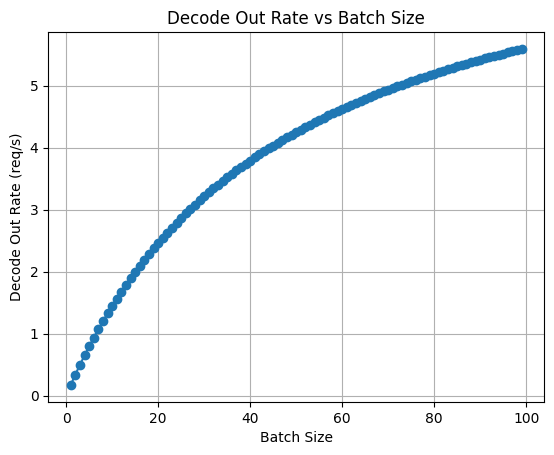

In [ ]:
rate_model = DisaggregationRateModel('llama-7b', 2, 128, 256)
res = []
for bs in range(1, 100):
    res.append(rate_model.decode_model.get_out_rate(bs))
plt.plot(range(1, 100), res, marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Decode Out Rate (req/s)')
plt.title('Decode Out Rate vs Batch Size')
plt.grid(True)
plt.show()

### Decode Out Rate vs Output Length Ratio

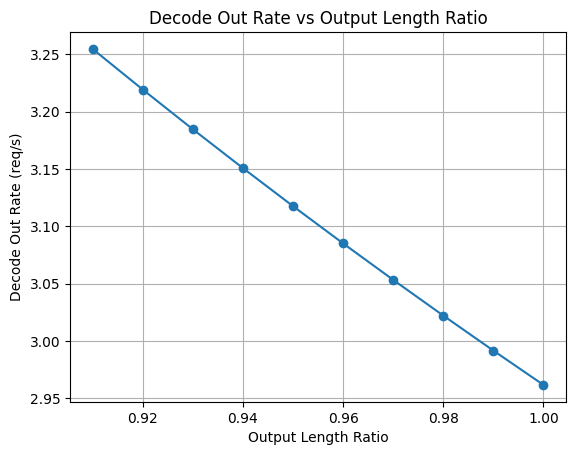

In [ ]:
rate_model = DisaggregationRateModel('llama-7b', 2, 128, 256)
res = []
output_len_ratios  = []

count = 10
start = 1 - count/100
for i in range(1, count+1):
    ratio = start + 0.01 * i
    output_len_ratios.append(ratio)
    rate_model = DisaggregationRateModel('llama-7b', 2, 128, 256, ratio)
    rate_model = DisaggregationRateModel('llama-7b', 2, 182, 473, ratio)
    res.append(rate_model.decode_model.get_out_rate())
plt.plot(output_len_ratios, res, marker='o')
plt.xlabel('Output Length Ratio')
plt.ylabel('Decode Out Rate (req/s)')
plt.title('Decode Out Rate vs Output Length Ratio')
plt.grid(True)
plt.show()


### Batch Size vs QPS

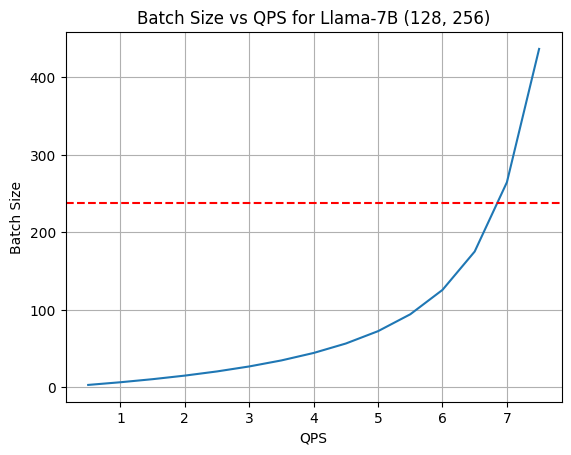

In [20]:

m = DecodeRateModel('llama-7b', 2, 7.442236861472422, 128, 256)
m = DecodeRateModel('llama-7b', 2, 6.59744, 182, 473)
qps = []
res = []
input_len = 128
output_len = 256
for i in range(1, 16):
    i = i / 2
    m = DecodeRateModel('llama-7b', i, 7.442236861472422, input_len, output_len)
    # m = DecodeRateModel('llama-7b', i, 6.59744, 182, 473)
    res.append(m.get_batch_size_according_to_qps())
    qps.append(i)
decode_max_batch_size = m.get_max_batch_size()
plt.plot(qps, res)
plt.xlabel('QPS')
plt.ylabel('Batch Size')
plt.axhline(y=decode_max_batch_size, color='r', linestyle='--', label='Max Batch Size')
plt.title(f'Batch Size vs QPS for Llama-7B ({input_len}, {output_len})')
plt.grid(True)
plt.show()


### Max Prefill/Decode Rate vs Prompt Len

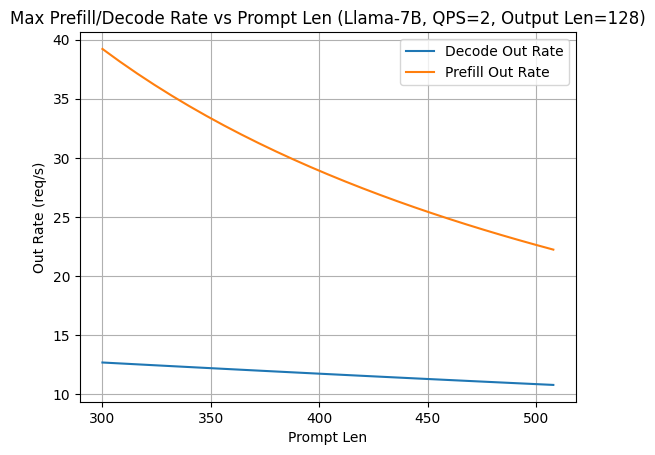

In [ ]:
max_decode_out_rate = []
max_prefill_out_rate = []
prompt_lens = range(300, 513, 8)
for i in prompt_lens:
    m = DisaggregationRateModel('llama-7b', 2, i, 128)
    max_decode_out_rate.append(m.decode_model.get_out_rate())
    max_prefill_out_rate.append(m.prefill_model.get_deal_max_rare())
plt.plot(prompt_lens, max_decode_out_rate, label='Decode Out Rate')
plt.plot(prompt_lens, max_prefill_out_rate, label='Prefill Out Rate')
plt.xlabel('Prompt Len')
plt.ylabel('Out Rate (req/s)')
plt.title('Max Prefill/Decode Rate vs Prompt Len (Llama-7B, QPS=2, Output Len=128)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def calculate_avg_step_time(results):
    # 计算每个inference_type和token_num的平均step_time
    avg_results = {
        'prefill': {},
        'decode': {},
    }
    for inference_type in results:
        for token_num, step_times in results[inference_type].items():
            step_times = np.array(step_times, dtype=float)
            avg_step_time = mean(step_times)
            avg_results[inference_type][token_num] = avg_step_time
    return avg_results

# 拟合token_num和avg_step_time的关系
def fit_token_num_vs_avg_step_time(token_nums, avg_step_times, inference_type):

    if len(token_nums) < 2:
        print(f"Not enough data to fit for {inference_type}.")
        return None
    
    # 使用numpy的polyfit进行线性拟合
    if inference_type == 'prefill':
        # 线性拟合
        coefficients = np.polyfit(token_nums, avg_step_times, 2)
    elif inference_type == 'decode':
        # 二次多项式拟合
        coefficients = np.polyfit(token_nums, avg_step_times, 2)
    fit_results = coefficients
    return fit_results

# 绘制token_num和avg_step_time的关系图,使用matplotlib,
def plot_token_num_vs_avg_step_time(results):
    avg_results = calculate_avg_step_time(results)
    # 分配两个子图
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    for i, inference_type in enumerate(avg_results):
        token_nums = list(avg_results[inference_type].keys())
        avg_step_times = list(avg_results[inference_type].values())

        token_nums = np.array(token_nums, dtype=float)
        avg_step_times = np.array(avg_step_times, dtype=float)

        sort_idx = np.argsort(token_nums)
        token_nums = token_nums[sort_idx]
        avg_step_times = avg_step_times[sort_idx]

        # 剔除异常值
        if len(token_nums) > 2:
            # 基于IQR方法剔除异常值
            q1 = np.percentile(avg_step_times, 25)
            q3 = np.percentile(avg_step_times, 75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
            mask = (avg_step_times >= lower_bound) & (avg_step_times <= upper_bound)
            token_nums = token_nums[mask]
            avg_step_times = avg_step_times[mask]
        axs[i].scatter(token_nums, avg_step_times, label=f'{inference_type} data', color='red', s=10)
        # 拟合曲线
        fit_results = fit_token_num_vs_avg_step_time(token_nums, avg_step_times, inference_type)
        if fit_results is not None:
            print(f'Fitting results for {inference_type}: {fit_results}')
            fit_line = np.polyval(fit_results, token_nums)
            axs[i].plot(token_nums, fit_line, label=f'{inference_type} fit', color='orange')
        axs[i].set_title(f'Token Num vs Avg Step Time for {inference_type}')
        axs[i].set_xlabel('Token Num')
        axs[i].set_ylabel('Avg Step Time (ms)')
        axs[i].legend()
        axs[i].grid(True)
    plt.tight_layout()
    plt.savefig(f'token_num_vs_avg_step_time.png')
    plt.show()
    
results = {        # [inference_type][token_num] = step_time:list
    'prefill': {},
    'decode': {},
}
for concurrency in [1, 2, 4, 8]:
    print(f"Processing concurrency: {concurrency}")
    instance_file_dir = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-{concurrency}-pdd-4/llama-7b/poisson'
    instance_profile = InstanceProfile(instance_file_dir, enable_pd=True)
    instance_profile.get_pdd_instance_info()
    # instance_profile.plot_token_num_vs_avg_step_time()
    for inference_type in instance_profile.results:
        print(f'Inference Type: {inference_type}')
        for token_num, avg_step_time in instance_profile.results[inference_type].items():
            if token_num not in results[inference_type]:
                results[inference_type][token_num] = []
            results[inference_type][token_num].extend(instance_profile.results[inference_type][token_num])
plot_token_num_vs_avg_step_time(results)

### not pd 建模

In [ ]:
class AggregationRateModel:
    def __init__(self, model_profiler_msg, workload_msg):
        self.in_rate = workload_msg['qps']
        self.prompt_len = workload_msg['prompt_len']
        self.output_len = workload_msg['output_len']
        self.fit_prefill_args = model_profiler_msg['prefill_msg']
        self.fit_decode_args = model_profiler_msg['decode_msg']

        gpu_block_num = model_profiler_msg['model_msg']['gpu_block']
        self.max_batch_size = gpu_block_num * BLOCK_SIZE / self.get_seq_len()
        self.max_seq_len = model_profiler_msg['model_msg']['max_seq_len']

    def get_in_rate(self):
        return self.in_rate

    def get_prefill_time(self, token_num=None):
        # y = a*x^2 + b*x + c
        latency_args = self.fit_prefill_args
        time = 0
        while token_num > self.max_seq_len:
            time += latency_args[0] * self.max_seq_len**2 + latency_args[1] * self.max_seq_len + latency_args[2]
            token_num -= self.max_seq_len
        # 计算剩余token_num的时间
        time += latency_args[0] * token_num**2 + latency_args[1] * token_num + latency_args[2]
        return time
    
    def get_seq_len(self):
        return self.prompt_len + 0.5 * self.output_len

    def get_decode_time(self, batch_size=None):
        if batch_size is None:
            batch_size = self.get_max_batch_size()
        args = self.fit_decode_args
        print((args[0] * batch_size + args[1] * self.get_seq_len() + args[2]))
        time = (args[0] * batch_size + args[1] * self.get_seq_len() + args[2]) * self.output_len
        return time

    # def get_deal_rare(self):
    #     args = self.fit_args
    #     return 1000 / (args[0] * self.prompt_len**2 + args[1]*self.prompt_len + args[2])
    
    def get_out_rate(self, batch_size):
        # print(self.get_prefill_time(self.prompt_len*batch_size),
        #       self.get_prefill_time(self.prompt_len) * batch_size, 
        #       self.get_prefill_time(self.prompt_len*self.in_rate),
        #       self.get_prefill_time(self.prompt_len)*self.in_rate,
        #       self.get_prefill_time(508))
        prefill_time = self.get_prefill_time(batch_size * self.prompt_len)       # 391.22709043703503 0.2431446590704659
        # prefill_time = self.get_prefill_time(508)                               # 146.6184449543714 0.24557897232779077
        # prefill_time = self.get_prefill_time(self.prompt_len)*batch_size    # 568.8139697206962 0.24140735889278755
        print(prefill_time, self.get_prefill_time(self.prompt_len))
        rate = batch_size / (prefill_time / 1000 + self.get_decode_time(batch_size) / 1000)
        return rate
    
m = ModelProfiler('llama-13b', profile_dir)
model_profiler_msg = m.profile_data
workload_msg = {
    'qps': 0.25,
    'prompt_len': 260,  # 182\260
    'output_len': 490,  # 473\490
}
rate_model = AggregationRateModel(model_profiler_msg, workload_msg)    # 182, 473
# print(rate_model.max_batch_size)
print(rate_model.get_out_rate(6))
# batch_size = [1, 2, 4, 8, 16, 32, 48, 64, 80, 96, 112, 128]
# out_rate = []
# for bs in batch_size:
#     out_rate.append(rate_model.get_out_rate(bs))
# plt.plot(batch_size, out_rate, marker='o')
# plt.axhline(y=rate_model.get_in_rate(), color='r', linestyle='--', label='Input Rate')
# plt.xlabel('Batch Size')
# plt.ylabel('Out Rate (req/s)')
# plt.title('Out Rate vs Batch Size')
# plt.legend()
# plt.grid(True)
# plt.show()

782.4541808740701 94.8023282867827
49.56212407143107
0.23934997357274107
